# Nonlinear Regression

The goals of this colab notebook include:

1. An example of a non-linear relationship in the data.
2. Simple feature generation allows us to use linear regression to obtain a non-linear fit.
3. We also look at skewness and data transformations.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
import pandas as pd
from pandas import DataFrame, Series
from pandas.plotting import scatter_matrix
import seaborn as sns
import scipy.stats
sns.set(style='ticks', palette='Set2')
%matplotlib inline

# Salary vs Experience

We load a data set that relates the salary received, vs years of experience. Our goal is to try to learn a relationship from years of experience to salary.

In [ ]:
# Upload the train file from your local drive
# For me, in ./Dropbox/Python/DataScience/
from google.colab import files
uploaded = files.upload()

Saving profsalary.txt to profsalary.txt


In [ ]:
print(profsalary.txt)

NameError: name 'profsalary' is not defined

In [ ]:
# We read the data
data_try = pd.read_csv("profsalary.txt", header=None, delimiter=r"\s+")
print(data_try)

        0       1           2
0    Case  Salary  Experience
1       1      71          26
2       2      69          19
3       3      73          22
4       4      69          17
..    ...     ...         ...
139   139      43           3
140   140      63          12
141   141      67          16
142   142      71          20
143   143      69          31

[144 rows x 3 columns]


In [ ]:
# Looks like we read in the index as a feature. Don't want that.
data = data_try.iloc[1:,1:3]
print(data)

      1   2
1    71  26
2    69  19
3    73  22
4    69  17
5    65  13
..   ..  ..
139  43   3
140  63  12
141  67  16
142  71  20
143  69  31

[143 rows x 2 columns]


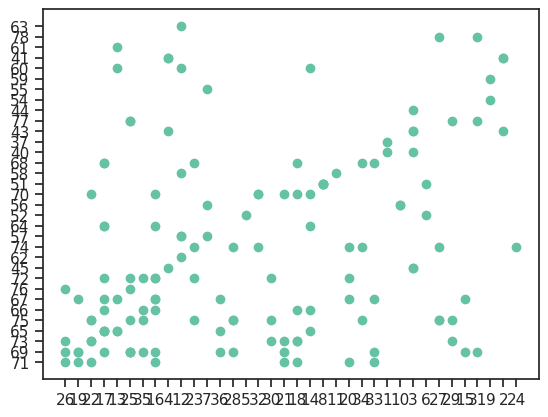

In [ ]:
# Let's put the data into numpy arrays and plot
salary = np.array(data.iloc[:,0])
experience = np.array(data.iloc[:,1])
plt.scatter(experience,salary)

# So can we conclude: there doesn't seem to be a relationship?


In [ ]:
# That's a trick question....
# That's one weird looking plot. Why are the numbers out of order??
#
# Look again at plotting two numpy arrays... nope, nothing there
# gives a hint as to what's going on...
#
# Let's look again at the data without the "print" function I used above.

salary

array(['71', '69', '73', '69', '65', '75', '66', '66', '67', '69', '76',
       '72', '69', '45', '72', '62', '74', '65', '73', '57', '64', '67',
       '75', '52', '69', '56', '70', '72', '75', '73', '71', '65', '69',
       '51', '58', '72', '68', '68', '69', '67', '65', '73', '69', '51',
       '67', '71', '40', '68', '65', '75', '67', '73', '51', '56', '40',
       '73', '65', '69', '65', '66', '37', '52', '51', '51', '71', '69',
       '71', '43', '72', '57', '71', '75', '77', '68', '74', '72', '70',
       '44', '67', '57', '69', '76', '69', '67', '77', '75', '72', '54',
       '55', '70', '59', '75', '60', '69', '75', '73', '64', '75', '64',
       '71', '41', '75', '56', '61', '58', '70', '43', '74', '70', '75',
       '72', '74', '67', '68', '73', '41', '60', '78', '77', '45', '60',
       '69', '70', '68', '64', '41', '77', '66', '43', '78', '74', '70',
       '66', '41', '75', '74', '45', '74', '43', '63', '67', '71', '69'],
      dtype=object)

In [ ]:
# Aha! There's our mistake. We inadvertently read in the numbers as strings, which explains the
# strange looking plot above.
#
# Now back to the documentation for DataFrame.read_csv to figure out
# how to make sure we're reading in the numbers as numbers and not as a string.
#
data_nexttry = pd.read_csv("profsalary.txt", header=0, delimiter=r"\s+", dtype=float)
print(data)

      1   2
1    71  26
2    69  19
3    73  22
4    69  17
5    65  13
..   ..  ..
139  43   3
140  63  12
141  67  16
142  71  20
143  69  31

[143 rows x 2 columns]


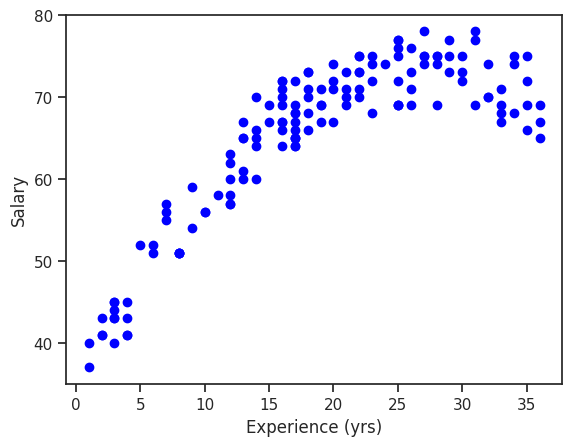

In [ ]:
# Now let's try again to load as a numpy array and plot
salary_t2 = np.array(data_nexttry.iloc[:,1])
experience_t2 = np.array(data_nexttry.iloc[:,2])
plt.plot(experience_t2,salary_t2,"ob")
plt.ylabel('Salary')
plt.xlabel('Experience (yrs)')
#plt.title('Salary vs Experience')
plt.show()

In [ ]:
experience_t2

array([26., 19., 22., 17., 13., 25., 35., 16., 16., 16., 26., 16., 25.,
        4., 17., 12., 23., 17., 26.,  7., 17., 36., 28.,  5., 25.,  7.,
       32., 30., 35., 21., 18., 14., 35.,  8., 11., 20., 17., 34., 26.,
       33., 36., 22., 19.,  8., 20., 22.,  1., 18., 17., 28., 17., 30.,
        8., 10.,  3., 18., 17., 33., 13., 14.,  1.,  6.,  8.,  6., 19.,
       36., 16.,  3., 25., 12., 21., 27., 29., 23., 27., 23., 14.,  3.,
       15., 12., 25., 25., 28., 19., 31., 27., 16.,  9.,  7., 16.,  9.,
       29., 12., 15., 22., 18., 17., 23., 16., 33.,  2., 34., 10., 13.,
       12., 22.,  2., 20., 21., 22., 35., 34., 13., 17., 29.,  2., 14.,
       31., 25.,  3., 13., 21., 18., 33., 14.,  4., 25., 18.,  4., 27.,
       32., 32., 17.,  4., 30., 24.,  3., 28.,  3., 12., 16., 20., 31.])

Model we want is:
X = experience
y = salary

y = βX + β0

In [ ]:
mymodel = linear_model.LinearRegression()


In [ ]:
experience_t2.shape

(143,)

In [ ]:
mymodel.fit(experience_t2.reshape(-1,1),salary_t2)

LinearRegression()

In [ ]:
X=experience_t2.reshape(-1,1)
y = salary_t2

This is not going to be a very good fit -- we can all see that the data look parabolic -- maybe a quadratic fit would be better

y = β0 + βexperience + β_2 experience^2

In [ ]:
X

array([[26.],
       [19.],
       [22.],
       [17.],
       [13.],
       [25.],
       [35.],
       [16.],
       [16.],
       [16.],
       [26.],
       [16.],
       [25.],
       [ 4.],
       [17.],
       [12.],
       [23.],
       [17.],
       [26.],
       [ 7.],
       [17.],
       [36.],
       [28.],
       [ 5.],
       [25.],
       [ 7.],
       [32.],
       [30.],
       [35.],
       [21.],
       [18.],
       [14.],
       [35.],
       [ 8.],
       [11.],
       [20.],
       [17.],
       [34.],
       [26.],
       [33.],
       [36.],
       [22.],
       [19.],
       [ 8.],
       [20.],
       [22.],
       [ 1.],
       [18.],
       [17.],
       [28.],
       [17.],
       [30.],
       [ 8.],
       [10.],
       [ 3.],
       [18.],
       [17.],
       [33.],
       [13.],
       [14.],
       [ 1.],
       [ 6.],
       [ 8.],
       [ 6.],
       [19.],
       [36.],
       [16.],
       [ 3.],
       [25.],
       [12.],
       [21.],
      

In [ ]:
# make a new X where the second column is the first column squared
X = np.zeros([experience_t2.shape[0],2])
X[:,0] = experience_t2;
X[:,1] = experience_t2**2

In [ ]:
X

array([[2.600e+01, 6.760e+02],
       [1.900e+01, 3.610e+02],
       [2.200e+01, 4.840e+02],
       [1.700e+01, 2.890e+02],
       [1.300e+01, 1.690e+02],
       [2.500e+01, 6.250e+02],
       [3.500e+01, 1.225e+03],
       [1.600e+01, 2.560e+02],
       [1.600e+01, 2.560e+02],
       [1.600e+01, 2.560e+02],
       [2.600e+01, 6.760e+02],
       [1.600e+01, 2.560e+02],
       [2.500e+01, 6.250e+02],
       [4.000e+00, 1.600e+01],
       [1.700e+01, 2.890e+02],
       [1.200e+01, 1.440e+02],
       [2.300e+01, 5.290e+02],
       [1.700e+01, 2.890e+02],
       [2.600e+01, 6.760e+02],
       [7.000e+00, 4.900e+01],
       [1.700e+01, 2.890e+02],
       [3.600e+01, 1.296e+03],
       [2.800e+01, 7.840e+02],
       [5.000e+00, 2.500e+01],
       [2.500e+01, 6.250e+02],
       [7.000e+00, 4.900e+01],
       [3.200e+01, 1.024e+03],
       [3.000e+01, 9.000e+02],
       [3.500e+01, 1.225e+03],
       [2.100e+01, 4.410e+02],
       [1.800e+01, 3.240e+02],
       [1.400e+01, 1.960e+02],
       [

In [ ]:
mymodel = linear_model.LinearRegression()
mymodel.fit(X,salary_t2)

LinearRegression()

In [ ]:
# what are the coefficients of our new mdoel?
print(mymodel.coef_)
print(mymodel.intercept_)

[ 2.87227465 -0.05331609]
34.72049838515164


The model we just fit is:

y = 34.7 + 2.87*Experience -0.05*Experience^2

In [ ]:
# what are the parameters of my fitted model?
print(mymodel.coef_)
print(mymodel.intercept_)

[0.88344516]
48.505932868199395


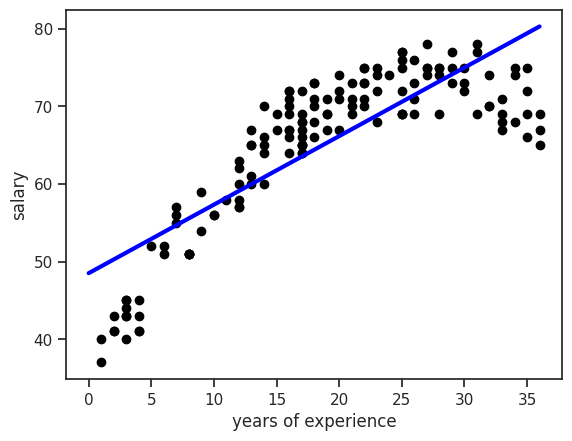

In [ ]:
# Let's try a linear fit
linreg = linear_model.LinearRegression()
linreg.fit(experience_t2.reshape(-1,1),salary_t2)

years = np.arange(37)
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.scatter(experience_t2, salary_t2,  color='black')
plt.plot(years, linreg.predict(years.reshape(-1,1)), color='blue',
         linewidth=3)

# Non-linear Fit

We will use feature generation to generate the "experience^2" column. Then we can just use linear regression again on the new data set.

In [ ]:
# We add a new column. Now we have 2 features
X = np.zeros([experience_t2.shape[0],2])
X[:,0] = experience_t2;
X[:,1] = experience_t2**2
y = salary_t2;

In [ ]:
# Again we fit a linear regression
lr = linear_model.LinearRegression()
lr.fit(X,y)
print("The coefficients of the linear and quadratic parts are: ",  lr.coef_)
print("The intercept is: ", lr.intercept_)

The coefficients of the linear and quadratic parts are:  [ 2.87227465 -0.05331609]
The intercept is:  34.72049838515164


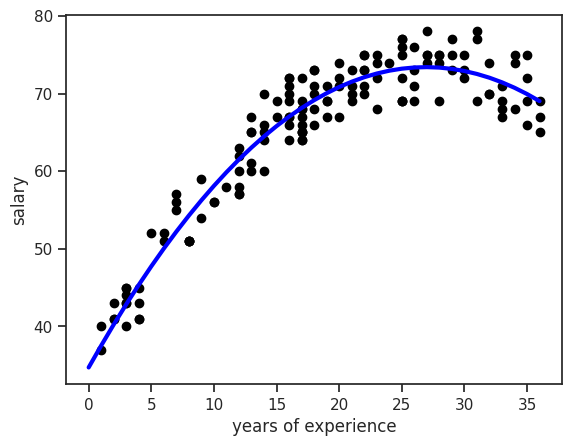

In [ ]:
# And we can plot the result. Much better!
years = np.arange(37)
yyears = np.zeros([years.shape[0],2])
yyears[:,0]=years;
yyears[:,1]=years**2;
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.scatter(experience_t2, salary_t2,  color='black')
plt.plot(years, lr.predict(yyears), color='blue',
         linewidth=3)

# Transforming Data
Salary data are often skewed. This is in fact a technical term, and we can compute a quantity called skewness. I have used a scipy.stats package to compute this, but I also wrote a function to compute skewness below, so that you can see how it is defined.

When data are skewed, meaning the skew value you compute is outside of [-0.5,0.5], it is often a good idea to apply a transformation like x --> log(1+x). I do this here, and then compute a quadratic fit in the new regime. Then I plot both lines. For this example, you'll see that they're both pretty close, though indeed they are different.



In [ ]:
# We see that the skew is out of the typical range
data_skew = scipy.stats.skew(y)
print('The skew of the data, as computed by scipy.stats.skew, is', data_skew) # it is outside [-0.5,0.5]
y_log = np.log1p(y) # so we transform it

The skew of the data, as computed by scipy.stats.skew, is -1.1720675246542613


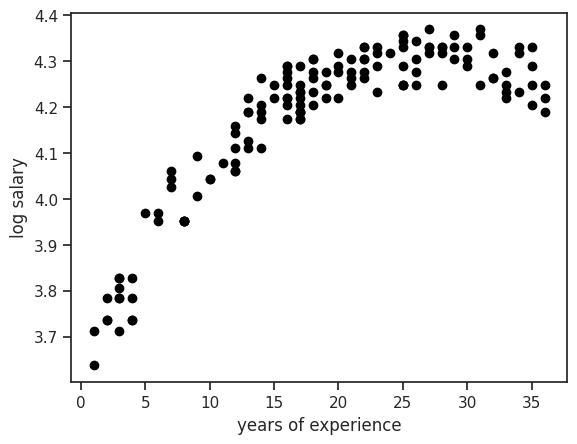

In [ ]:
# We can now replot, with the transformed salary data
plt.xlabel("years of experience")
plt.ylabel("log salary")
plt.scatter(experience_t2, y_log,  color='black')

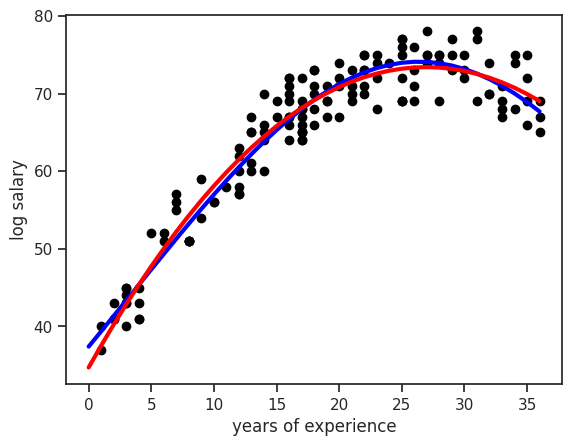

In [ ]:
# Now we can recompute the fit, and plot again against the original
lr_log = linear_model.LinearRegression()
lr_log.fit(X,y_log)
years = np.arange(37)
yyears = np.zeros([years.shape[0],2])
yyears[:,0]=years;
yyears[:,1]=years**2;
plt.xlabel("years of experience")
plt.ylabel("log salary")
plt.scatter(experience_t2, y,  color='black')
plt.plot(years, np.expm1(lr_log.predict(yyears)), color='blue',
         linewidth=3)
plt.plot(years, lr.predict(yyears), color='red',
         linewidth=3)